**Header**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf

BASE    = '/content/drive/MyDrive/churn_project/'
PROC    = BASE + 'data/processed/'
RESULTS = BASE + 'results/'

print("✓ Ready")

Mounted at /content/drive
✓ Ready


**Load Everything needed:**

In [2]:
# Load preprocessed data
with open(PROC + 'final_data.pkl', 'rb') as f:
    final_data = pickle.load(f)

# Load CNN models
with open(PROC + 'lfe_models.pkl', 'rb') as f:
    lfe_models = pickle.load(f)

with open(PROC + 'dfe_models.pkl', 'rb') as f:
    dfe_models = pickle.load(f)

# Load XGBoost models
with open(PROC + 'xgb_models.pkl', 'rb') as f:
    xgb_models = pickle.load(f)

datasets = ['Insurance', 'ISP', 'Telecom']

print("✓ All models loaded")
for name in datasets:
    print(f"  {name:12} → "
          f"test: {final_data[name]['X_test'].shape}")
print("✓ Preprocessed data loaded")

✓ All models loaded
  Insurance    → test: (11977, 16)
  ISP          → test: (14455, 9)
  Telecom      → test: (667, 19)
✓ Preprocessed data loaded


**Reshape Test data for CNN input:**

In [3]:
# CNNs need 3D input — reshape test sets
cnn_test = {}

for name in datasets:
    X_test    = final_data[name]['X_test'].values
    X_test_3d = X_test.reshape(
        X_test.shape[0], X_test.shape[1], 1)

    cnn_test[name] = {
        'X_test_3d' : X_test_3d,
        'X_test_2d' : X_test,
        'y_test'    : final_data[name]['y_test'].values
    }
    print(f"{name:12} → "
          f"3D: {X_test_3d.shape}  "
          f"2D: {X_test.shape}")

print("\n✓ Test data reshaped")

Insurance    → 3D: (11977, 16, 1)  2D: (11977, 16)
ISP          → 3D: (14455, 9, 1)  2D: (14455, 9)
Telecom      → 3D: (667, 19, 1)  2D: (667, 19)

✓ Test data reshaped


**Build ensemble (average LFE + DFE probabilities)**

In [4]:
# Paper's ensemble method:
# Final probability = average of LFE-CNN and DFE-CNN output probabilities
# This is the paper's main contribution

from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, cohen_kappa_score,
                              confusion_matrix)

ensemble_results = []
ensemble_probs   = {}   # save for ROC curve plotting

for name in datasets:
    X_test_3d = cnn_test[name]['X_test_3d']
    y_test    = cnn_test[name]['y_test']

    # Get probability outputs from both CNNs
    lfe_prob = lfe_models[name].predict(X_test_3d, verbose=0).flatten()
    dfe_prob = dfe_models[name].predict(X_test_3d, verbose=0).flatten()

    # Ensemble — average the two probability outputs
    ensemble_prob = (lfe_prob + dfe_prob) / 2
    ensemble_pred = (ensemble_prob >= 0.5).astype(int)

    # Save probabilities for later plots
    ensemble_probs[name] = {
        'lfe_prob'      : lfe_prob,
        'dfe_prob'      : dfe_prob,
        'ensemble_prob' : ensemble_prob
    }

    # Evaluate
    acc   = accuracy_score(y_test, ensemble_pred)
    prec  = precision_score(y_test, ensemble_pred, zero_division=0)
    rec   = recall_score(y_test, ensemble_pred, zero_division=0)
    f1    = f1_score(y_test, ensemble_pred, zero_division=0)
    auc   = roc_auc_score(y_test, ensemble_prob)
    kappa = cohen_kappa_score(y_test, ensemble_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, ensemble_pred).ravel()

    ensemble_results.append({
        'Dataset'     : name,
        'Model'       : 'Ensemble (LFE+DFE)',
        'Accuracy'    : round(acc   * 100, 2),
        'Precision'   : round(prec  * 100, 2),
        'Recall'      : round(rec   * 100, 2),
        'F1 Score'    : round(f1    * 100, 2),
        'ROC AUC'     : round(auc   * 100, 2),
        'Kappa'       : round(kappa,        4),
        'Specificity' : round(tn/(tn+fp) * 100, 2),
        'True Churn'  : int(tp),
        'False Churn' : int(fp)
    })

    print(f"\n{name} Ensemble Results:")
    print(f"  Accuracy  : {round(acc*100,2)}%")
    print(f"  Precision : {round(prec*100,2)}%")
    print(f"  Recall    : {round(rec*100,2)}%")
    print(f"  F1 Score  : {round(f1*100,2)}%")
    print(f"  ROC AUC   : {round(auc*100,2)}%")
    print(f"  Kappa     : {round(kappa,4)}")

ensemble_df = pd.DataFrame(ensemble_results)
display(ensemble_df)


Insurance Ensemble Results:
  Accuracy  : 95.43%
  Precision : 92.37%
  Recall    : 99.05%
  F1 Score  : 95.59%
  ROC AUC   : 97.88%
  Kappa     : 0.9087

ISP Ensemble Results:
  Accuracy  : 92.68%
  Precision : 94.12%
  Recall    : 92.57%
  F1 Score  : 93.34%
  ROC AUC   : 97.14%
  Kappa     : 0.8522

Telecom Ensemble Results:
  Accuracy  : 80.66%
  Precision : 41.24%
  Recall    : 84.21%
  F1 Score  : 55.36%
  ROC AUC   : 84.91%
  Kappa     : 0.4481


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Kappa,Specificity,True Churn,False Churn
0,Insurance,Ensemble (LFE+DFE),95.43,92.37,99.05,95.59,97.88,0.9087,91.82,5931,490
1,ISP,Ensemble (LFE+DFE),92.68,94.12,92.57,93.34,97.14,0.8522,92.82,7415,463
2,Telecom,Ensemble (LFE+DFE),80.66,41.24,84.21,55.36,84.91,0.4481,80.07,80,114


**Master results table (ALL models together)**

In [5]:
# Load individual model results
xgb_df = pd.read_csv(RESULTS + 'xgboost_results.csv')
cnn_df = pd.read_csv(RESULTS + 'cnn_results.csv')

# Verify CNN results are from correct run
print("CNN results loaded:")
print(cnn_df[['Dataset', 'Model', 'Accuracy']])
print("\nExpected ISP LFE-CNN: ~91%")
print("Expected ISP DFE-CNN: ~93%")
print("If numbers look wrong, cnn_results.csv is from old run")
print("In that case paste new results manually\n")

# Combine everything into one master table
master_df = pd.concat([xgb_df, cnn_df, ensemble_df],
                       ignore_index=True)

master_df = master_df.sort_values(
    ['Dataset', 'Accuracy'],
    ascending=[True, False]
).reset_index(drop=True)

print("="*70)
print("  MASTER RESULTS TABLE — ALL MODELS ALL DATASETS")
print("="*70)
display(master_df[['Dataset','Model','Accuracy',
                   'Precision','Recall','F1 Score',
                   'ROC AUC','Kappa']])

master_df.to_csv(RESULTS + 'master_results.csv', index=False)
print("\n✓ Saved → results/master_results.csv")

CNN results loaded:
     Dataset    Model  Accuracy
0  Insurance  LFE-CNN     95.83
1  Insurance  DFE-CNN     92.70
2        ISP  LFE-CNN     91.29
3        ISP  DFE-CNN     93.25
4    Telecom  LFE-CNN     83.51
5    Telecom  DFE-CNN     86.36

Expected ISP LFE-CNN: ~91%
Expected ISP DFE-CNN: ~93%
If numbers look wrong, cnn_results.csv is from old run
In that case paste new results manually

  MASTER RESULTS TABLE — ALL MODELS ALL DATASETS


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Kappa
0,ISP,XGBoost,94.08,95.91,93.30,94.58,98.08,0.8806
1,ISP,DFE-CNN,93.25,93.67,94.19,93.93,97.51,0.8634
2,ISP,Ensemble (LFE+DFE),92.68,94.12,92.57,93.34,97.14,0.8522
3,ISP,LFE-CNN,91.29,91.29,93.17,92.22,96.00,0.8233
4,Insurance,LFE-CNN,95.83,93.69,98.26,95.92,98.04,0.9165
5,Insurance,Ensemble (LFE+DFE),95.43,92.37,99.05,95.59,97.88,0.9087
6,Insurance,DFE-CNN,92.70,89.52,96.73,92.98,96.57,0.8541
7,Insurance,XGBoost,89.94,87.45,93.25,90.26,95.57,0.7988
8,Telecom,XGBoost,95.05,82.98,82.11,82.54,92.28,0.7966
9,Telecom,DFE-CNN,86.36,51.41,76.84,61.60,86.46,0.5370



✓ Saved → results/master_results.csv


**ROC curves — all models on one chart per dataset**

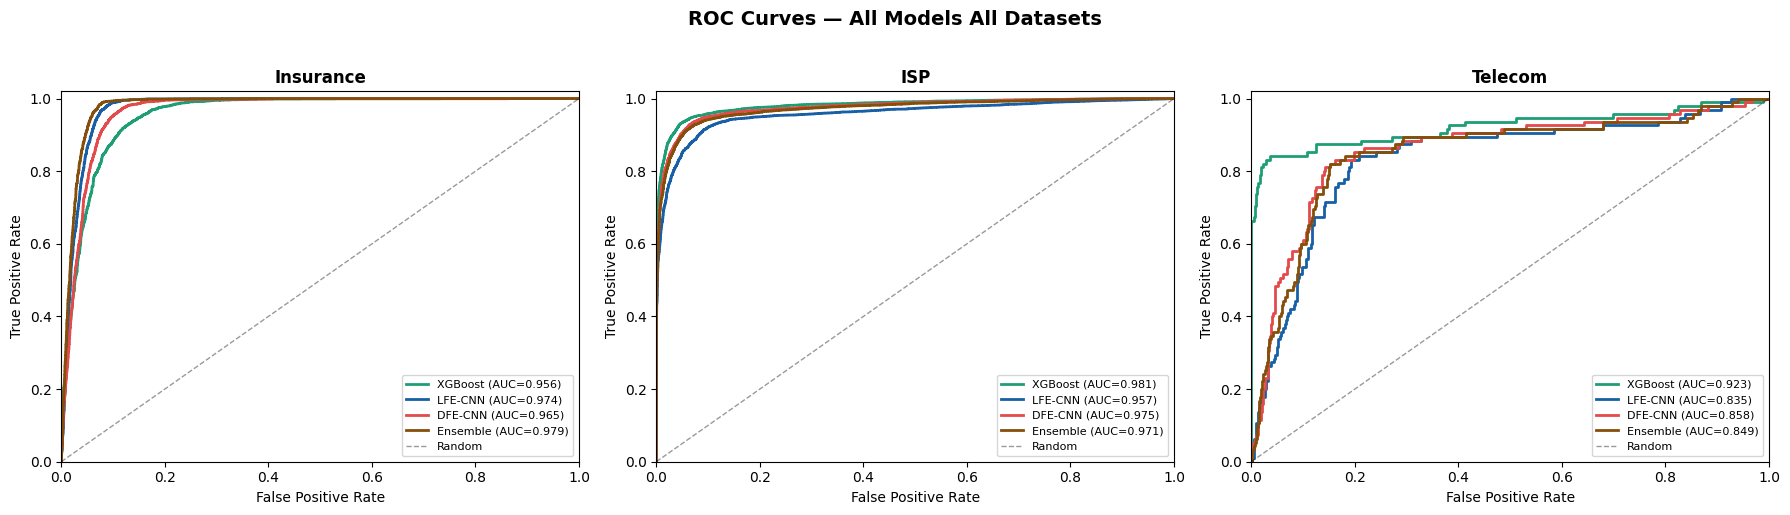

✓ Saved → results/all_models_roc_curves.png


In [6]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_colors = {
    'XGBoost'          : '#1D9E75',
    'LFE-CNN'          : '#185FA5',
    'DFE-CNN'          : '#E24B4A',
    'Ensemble (LFE+DFE)': '#854F0B'
}

for ax, name in zip(axes, datasets):
    y_test    = cnn_test[name]['y_test']
    X_test_3d = cnn_test[name]['X_test_3d']
    X_test_2d = cnn_test[name]['X_test_2d']

    # XGBoost
    xgb_prob = xgb_models[name].predict_proba(X_test_2d)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, xgb_prob)
    auc = roc_auc_score(y_test, xgb_prob)
    ax.plot(fpr, tpr, color=model_colors['XGBoost'],
            linewidth=2, label=f"XGBoost (AUC={auc:.3f})")

    # LFE-CNN
    lfe_prob = ensemble_probs[name]['lfe_prob']
    fpr, tpr, _ = roc_curve(y_test, lfe_prob)
    auc = roc_auc_score(y_test, lfe_prob)
    ax.plot(fpr, tpr, color=model_colors['LFE-CNN'],
            linewidth=2, label=f"LFE-CNN (AUC={auc:.3f})")

    # DFE-CNN
    dfe_prob = ensemble_probs[name]['dfe_prob']
    fpr, tpr, _ = roc_curve(y_test, dfe_prob)
    auc = roc_auc_score(y_test, dfe_prob)
    ax.plot(fpr, tpr, color=model_colors['DFE-CNN'],
            linewidth=2, label=f"DFE-CNN (AUC={auc:.3f})")

    # Ensemble
    ens_prob = ensemble_probs[name]['ensemble_prob']
    fpr, tpr, _ = roc_curve(y_test, ens_prob)
    auc = roc_auc_score(y_test, ens_prob)
    ax.plot(fpr, tpr, color=model_colors['Ensemble (LFE+DFE)'],
            linewidth=2, label=f"Ensemble (AUC={auc:.3f})")

    # Baseline
    ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4, label='Random')

    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('ROC Curves — All Models All Datasets',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS + 'all_models_roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → results/all_models_roc_curves.png")

**Bar chart comparing all models**

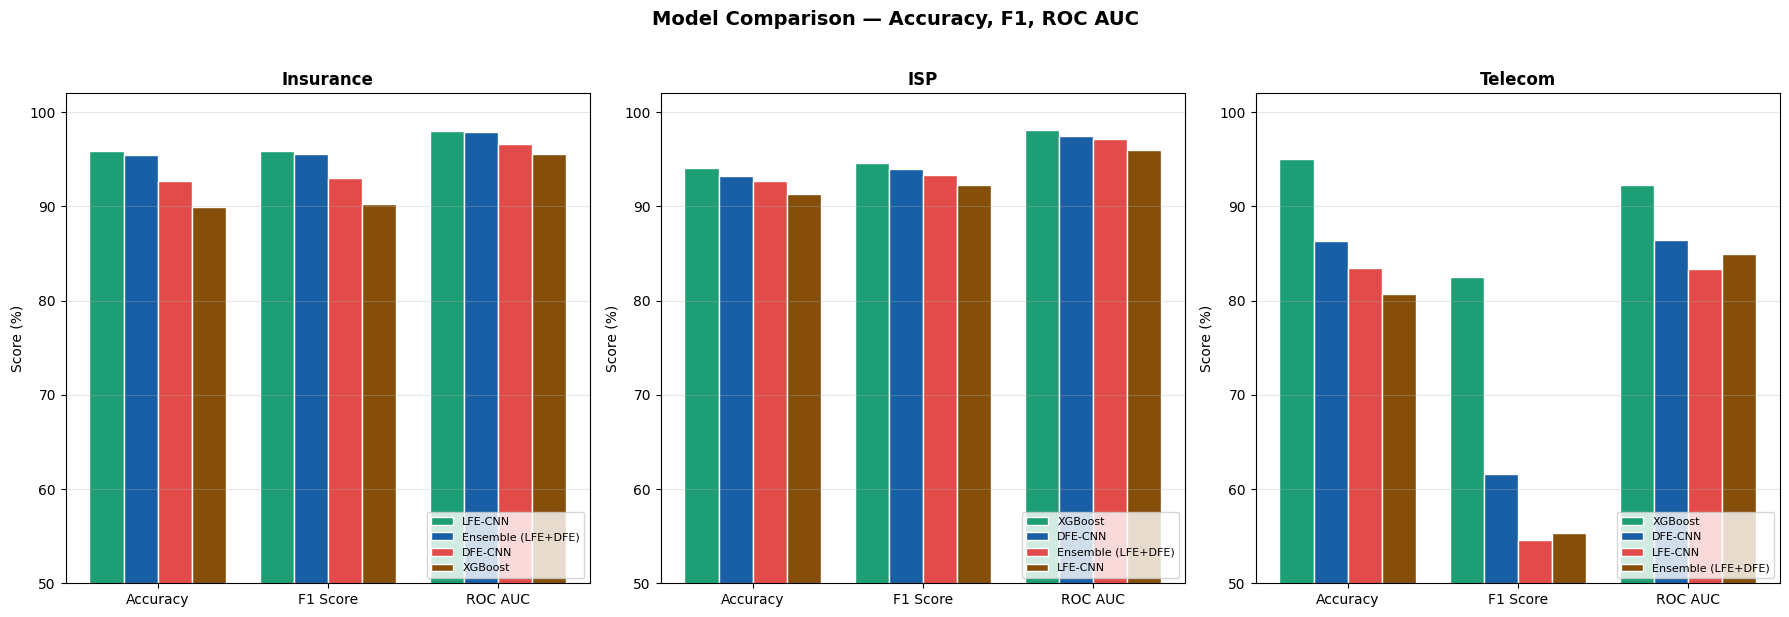

✓ Saved → results/model_comparison_bar.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics   = ['Accuracy', 'F1 Score', 'ROC AUC']
bar_colors = ['#1D9E75', '#185FA5', '#E24B4A', '#854F0B']

for ax, name in zip(axes, datasets):
    subset  = master_df[master_df['Dataset'] == name].reset_index(drop=True)
    x       = np.arange(len(metrics))
    n_models= len(subset)
    width   = 0.2

    for i, (_, row) in enumerate(subset.iterrows()):
        vals = [row['Accuracy'], row['F1 Score'], row['ROC AUC']]
        bars = ax.bar(x + i*width, vals,
                      width   = width,
                      label   = row['Model'],
                      color   = bar_colors[i % len(bar_colors)],
                      edgecolor='white')

    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_xticks(x + width * (n_models-1) / 2)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylabel('Score (%)')
    ax.set_ylim([50, 102])
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison — Accuracy, F1, ROC AUC',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS + 'model_comparison_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → results/model_comparison_bar.png")

**Final replication summary**

In [8]:
print("="*65)
print("  REPLICATION COMPLETE — FINAL SUMMARY")
print("="*65)

paper_targets = {
    'Insurance' : {'Accuracy': 93.0, 'note': 'Ensemble target'},
    'ISP'       : {'Accuracy': 96.0, 'note': 'Ensemble target'},
    'Telecom'   : {'Accuracy': 98.0, 'note': 'Ensemble target'}
}

for name in datasets:
    subset = master_df[master_df['Dataset'] == name]
    best   = subset.loc[subset['Accuracy'].idxmax()]
    target = paper_targets[name]['Accuracy']
    diff   = best['Accuracy'] - target
    status = '✅ Beat paper' if diff >= 0 else f'⚠️  {abs(diff):.1f}% below paper'

    print(f"\n{name}")
    print(f"  Best model    : {best['Model']}")
    print(f"  Best accuracy : {best['Accuracy']}%")
    print(f"  Paper target  : {target}%")
    print(f"  Status        : {status}")

print("\n" + "="*65)
print("  FILES SAVED TO GOOGLE DRIVE")
print("="*65)
saved_files = [
    'results/master_results.csv',
    'results/all_models_roc_curves.png',
    'results/model_comparison_bar.png',
    'results/xgboost_results.csv',
    'results/cnn_results.csv',
    'results/preprocessing_summary.csv',
    'results/eda_summary.csv'
]
for f in saved_files:
    print(f"  ✓ {f}")

print("\n✓ Replication phase 100% complete")
print("✓ Next phase: 06_improvements notebook")

  REPLICATION COMPLETE — FINAL SUMMARY

Insurance
  Best model    : LFE-CNN
  Best accuracy : 95.83%
  Paper target  : 93.0%
  Status        : ✅ Beat paper

ISP
  Best model    : XGBoost
  Best accuracy : 94.08%
  Paper target  : 96.0%
  Status        : ⚠️  1.9% below paper

Telecom
  Best model    : XGBoost
  Best accuracy : 95.05%
  Paper target  : 98.0%
  Status        : ⚠️  3.0% below paper

  FILES SAVED TO GOOGLE DRIVE
  ✓ results/master_results.csv
  ✓ results/all_models_roc_curves.png
  ✓ results/model_comparison_bar.png
  ✓ results/xgboost_results.csv
  ✓ results/cnn_results.csv
  ✓ results/preprocessing_summary.csv
  ✓ results/eda_summary.csv

✓ Replication phase 100% complete
✓ Next phase: 06_improvements notebook


**Saving of ensemble results**

In [9]:
import pickle

# Save ensemble results
ensemble_df.to_csv(RESULTS + 'ensemble_results.csv', index=False)
print("✓ ensemble_results.csv saved")

# Save ensemble probs for improvements notebook
with open(PROC + 'ensemble_probs.pkl', 'wb') as f:
    pickle.dump(ensemble_probs, f)
print("✓ ensemble_probs.pkl saved")

# Save master results
master_df.to_csv(RESULTS + 'master_results.csv', index=False)
print("✓ master_results.csv saved")

# Final file check
import os
print("\nAll result files:")
for f in sorted(os.listdir(RESULTS)):
    size = os.path.getsize(RESULTS + f) / 1024
    print(f"  {f:45} → {size:.1f} KB")

✓ ensemble_results.csv saved
✓ ensemble_probs.pkl saved
✓ master_results.csv saved

All result files:
  all_models_roc_curves.png                     → 141.0 KB
  churn_distribution.png                        → 97.4 KB
  cnn_results.csv                               → 0.5 KB
  cnn_training_history.png                      → 373.4 KB
  correlation_matrix.png                        → 392.3 KB
  eda_summary.csv                               → 0.2 KB
  ensemble_results.csv                          → 0.3 KB
  insurance_distributions.png                   → 185.4 KB
  isp_distributions.png                         → 204.9 KB
  master_results.csv                            → 0.9 KB
  model_comparison_bar.png                      → 70.9 KB
  preprocessing_summary.csv                     → 0.2 KB
  preprocessing_summary_corrected.csv           → 0.2 KB
  telecom_distributions.png                     → 258.0 KB
  xgboost_confusion_matrices.png                → 70.6 KB
  xgboost_feature_importance